# L1.17 — Random numbers and repeatability

**Level 1 · Core · 40 minutes**

**Goal.** Your results are the same every time you run them.

**Check at the end.** You can say why one shared generator breaks a comparison between two
conditions.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. One seed, a tree of streams

Every source of randomness in this library gets its **own** stream, and all of them come from one
root seed. That gives you two things at once: the whole study repeats from a single number, and the
sources stay independent of each other.

```python
root = root_seed_sequence(42)          # the root of the tree
nav, comm, broadcast = spawn(root, 3)  # three children
rng = generator(nav)                   # a leaf, ready to draw from
```

One rule governs the whole module, and breaking it is the source of most reproducibility bugs:

> A sequence is either an **internal node** that you spawn from, or a **leaf** that you make a
> generator from. Never both.

`spawn` is stateful. It hands out children starting from however many the parent has already
spawned, so spawning twice from one sequence **continues** rather than restarts.

In [1]:
%matplotlib inline
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, PURPLE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#9467bd"

from opencdarr import M600, create_aircraft, generator, root_seed_sequence, spawn
from opencdarr.rng import child, children

root = root_seed_sequence(42)
nav_seq, comm_seq, broadcast_seq = spawn(root, 3)

print(f"root entropy     {root.entropy}")
print(f"nav spawn_key    {nav_seq.spawn_key}")
print(f"comm spawn_key   {comm_seq.spawn_key}")
print(f"broadcast key    {broadcast_seq.spawn_key}")

print(f"\nfirst three draws from each leaf:")
for name, seq in (("nav", nav_seq), ("comm", comm_seq), ("broadcast", broadcast_seq)):
    print(f"  {name:<10}{np.round(generator(seq).normal(size=3), 4)}")

root entropy     42
nav spawn_key    (0,)
comm spawn_key   (1,)
broadcast key    (2,)

first three draws from each leaf:
  nav       [0.4183 0.6056 0.0288]
  comm      [ 1.2545  0.6063 -1.3402]
  broadcast [-1.6494  1.406   0.7235]


## 2. Repeat, and repeat again

The same seed gives the same numbers. That is the whole promise, and it is worth checking rather
than assuming.

In [2]:
first = generator(spawn(root_seed_sequence(42), 3)[0]).normal(size=5)
again = generator(spawn(root_seed_sequence(42), 3)[0]).normal(size=5)
other = generator(spawn(root_seed_sequence(43), 3)[0]).normal(size=5)

print(f"seed 42          {np.round(first, 4)}")
print(f"seed 42 again    {np.round(again, 4)}")
print(f"seed 43          {np.round(other, 4)}")
print(f"\n42 == 42:  {np.array_equal(first, again)}")
print(f"42 == 43:  {np.array_equal(first, other)}")

seed 42          [ 0.4183  0.6056  0.0288 -1.0842  1.4642]
seed 42 again    [ 0.4183  0.6056  0.0288 -1.0842  1.4642]
seed 43          [-0.0801 -1.9499  0.6395  0.7614  0.1028]

42 == 42:  True
42 == 43:  False


## 3. Reach one child without building its siblings

`spawn(parent, n)` materialises all `n` children. When `n` is two million encounters and a worker
needs only its own slice, that is wasteful.

`child(parent, i)` builds one child by **absolute index**, and `children(parent, start, stop)` builds
a half-open slice. They give the same tree:

```python
child(p, i) == spawn(p, n)[i]      for every n > i
children(p, 0, n) == spawn(p, n)
```

The equality holds exactly when `p` has not been spawned from yet — the rule of section 1 again.
Mix `spawn` and `child` on one parent and you re-use indices. Pick one.

In [3]:
parent = root_seed_sequence(7)
whole = spawn(root_seed_sequence(7), 6)
slice_ = children(root_seed_sequence(7), 2, 5)
single = child(root_seed_sequence(7), 3)

print(f"spawn(p, 6)[3] draws      {np.round(generator(whole[3]).normal(size=3), 4)}")
print(f"child(p, 3) draws         {np.round(generator(single).normal(size=3), 4)}")
print(f"children(p, 2, 5)[1] draws{np.round(generator(slice_[1]).normal(size=3), 4)}")
print(f"\nall three are the same stream: "
      f"{np.array_equal(generator(whole[3]).normal(size=3), generator(single).normal(size=3))}")

spawn(p, 6)[3] draws      [-1.0158 -0.9119 -0.1238]
child(p, 3) draws         [-1.0158 -0.9119 -0.1238]
children(p, 2, 5)[1] draws[-1.0158 -0.9119 -0.1238]

all three are the same stream: True


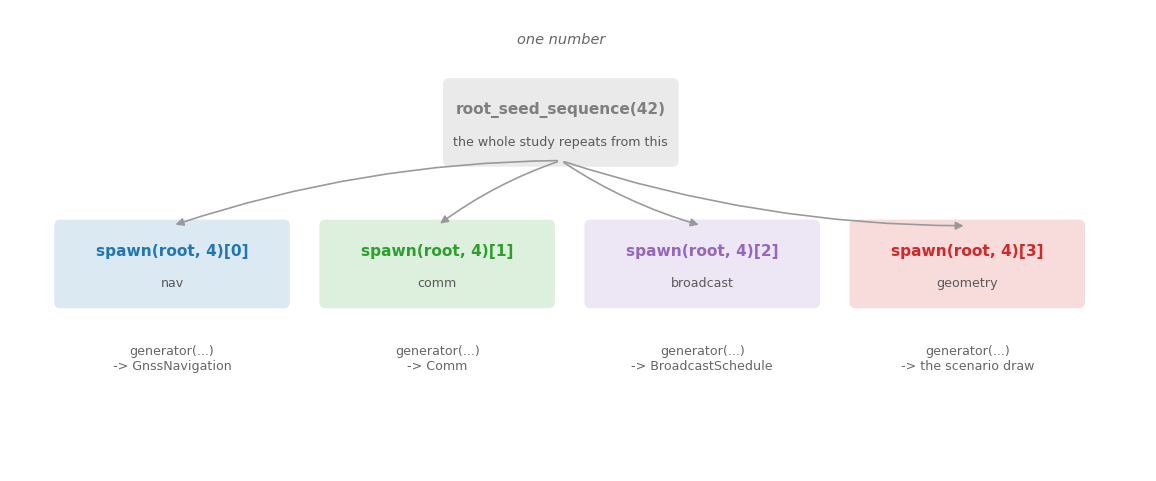

In [4]:
fig, ax = plt.subplots(figsize=(9.0, 3.8))

W, H = 1.9, 0.62


def box(x, y, title, subtitle, colour):
    ax.add_patch(FancyBboxPatch((x, y), W, H, boxstyle="round,pad=0.05", fc=colour, ec="none",
                                alpha=0.16))
    ax.text(x + W / 2, y + H * 0.66, title, ha="center", va="center", fontsize=8.5,
            color=colour, fontweight="bold")
    ax.text(x + W / 2, y + H * 0.24, subtitle, ha="center", va="center", fontsize=7, color="0.35")


box(3.3, 2.0, "root_seed_sequence(42)", "the whole study repeats from this", GREY)
leaves = [("nav", "GnssNavigation", BLUE), ("comm", "Comm", GREEN),
          ("broadcast", "BroadcastSchedule", PURPLE), ("geometry", "the scenario draw", RED)]
for k, (name, use, colour) in enumerate(leaves):
    x = k * 2.25
    box(x, 0.85, f"spawn(root, 4)[{k}]", name, colour)
    ax.add_patch(FancyArrowPatch((4.25, 2.0), (x + W / 2, 0.85 + H),
                                 arrowstyle="-|>", mutation_scale=9, color="0.6", lw=0.9,
                                 connectionstyle="arc3,rad=0.08"))
    ax.text(x + W / 2, 0.5, f"generator(...)\n-> {use}", ha="center", va="top", fontsize=7,
            color="0.4")

ax.text(4.25, 2.95, "one number", ha="center", fontsize=8, color="0.4", style="italic")
ax.set_xlim(-0.4, 9.2)
ax.set_ylim(-0.5, 3.2)
ax.axis("off")
fig.tight_layout()

## 4. Why the streams must be separate

Here is the failure this design prevents.

Give navigation and communication the **same** generator. They now draw from one sequence, in the
order the code happens to call them. If a change to the channel changes **how many draws it
consumes**, every navigation draw after that point shifts. The two conditions you wanted to compare
then differ in two ways — the thing you changed, and the noise — and any difference in the result
is unattributable.

Test two changes to the channel, and note that they behave differently:

- **A different `reception_prob`.** The channel spends one reception draw for each directed link
  whatever the probability is, so the draw *count* does not change. Navigation is safe even on a
  shared stream. This is deliberate: it is the same reason a link gate returns a boolean instead of
  a zero probability (lesson L1.15).
- **A latency distribution instead of a fixed delay.** `constant_latency` draws nothing;
  `uniform_latency` draws once for each accepted message. The count changes, so a shared stream
  contaminates navigation.

In [5]:
from opencdarr.cns import Comm, GnssNavigation, uniform_latency

FLEET = [create_aircraft(M600, id=name, lat=52.0, lon=4.0 + 0.004 * k, trk=90.0, gs=12.0,
                         pos_ci95=10.0, vel_ci95=1.0)
         for k, name in enumerate(("OWN", "INT"))]
NAV = GnssNavigation()


def fixes(comm, shared: bool, seed: int = 3, n: int = 40):
    """The measured latitudes of OWN, with the channel sharing or not sharing its stream."""
    if shared:
        one = generator(root_seed_sequence(seed))
        nav_rng = comm_rng = one
    else:
        nav_seq, comm_seq = spawn(root_seed_sequence(seed), 2)
        nav_rng, comm_rng = generator(nav_seq), generator(comm_seq)

    state = comm.initial_state()
    out = []
    for k in range(n):
        t = float(k)
        msgs = [NAV.measure(NAV.initial_state(), ac, t, nav_rng) for ac in FLEET]
        state = comm.step(state, msgs, FLEET, t, comm_rng)
        out.append(msgs[0].state.lat)
    return np.array(out)


BASE = Comm(reception_prob=0.9)
PROB = Comm(reception_prob=0.8)                                    # same draw count
DELAY = Comm(reception_prob=0.9, latency=uniform_latency(0.1, 0.5))  # one extra draw per delivery

print(f"{'stream layout':<24}{'change':<26}{'navigation unmoved':>20}")
for shared in (True, False):
    label = "one shared stream" if shared else "separate substreams"
    base = fixes(BASE, shared)
    for what, comm in (("reception_prob 0.9 -> 0.8", PROB), ("added a latency draw", DELAY)):
        same = np.array_equal(base, fixes(comm, shared))
        print(f"{label:<24}{what:<26}{str(same):>20}")

stream layout           change                      navigation unmoved
one shared stream       reception_prob 0.9 -> 0.8                 True
one shared stream       added a latency draw                     False
separate substreams     reception_prob 0.9 -> 0.8                 True
separate substreams     added a latency draw                      True


Read the four rows. The only `False` is the shared stream with a change that altered the draw count.
With separate substreams navigation never moves, whatever the channel does — so any difference in
the result belongs to the channel and to nothing else.

Do not rely on the first case being safe. It is safe for *this* change to *this* model. The next
change you make may consume a different number of draws, and nothing will tell you.

That is the rule for the rest of the course:

> One source of randomness, one substream. Always.

`run_fleet` takes them as separate arguments for exactly this reason:

```python
run_fleet(..., rng=generator(nav), comm_rng=generator(comm), broadcast_rng=generator(bcast))
```

And it **refuses** to run with broadcast jitter and no `broadcast_rng`, rather than quietly
borrowing another stream.

## 5. How a study is seeded

The pattern scales the same way at every level. One root, spawned per encounter, spawned again per
source inside that encounter:

```python
root = root_seed_sequence(config.seed)
for enc_seq in spawn(root, n_encounters):
    nav, comm, bcast = spawn(enc_seq, 3)
    ...
```

Two properties come out of that shape, and Level 6 needs both:

1. **Encounter *i* is the same run whatever else you do.** Running encounters 0–99 and then 100–199
   gives exactly the numbers you would get from 0–199 in one go.
2. **A worker can rebuild its own slice** with `children(root, start, stop)` and never touch its
   siblings. That is what makes `n_jobs=-1` produce numbers identical to `n_jobs=1`.

In [6]:
root = root_seed_sequence(0)
n = 200

# the whole study, and two chunks of it built independently
whole = [generator(s).normal() for s in spawn(root_seed_sequence(0), n)]
chunk_a = [generator(s).normal() for s in children(root_seed_sequence(0), 0, 80)]
chunk_b = [generator(s).normal() for s in children(root_seed_sequence(0), 80, n)]

print(f"encounters 0-79 from the chunk match the whole:   "
      f"{np.allclose(chunk_a, whole[:80])}")
print(f"encounters 80-199 from the chunk match the whole: "
      f"{np.allclose(chunk_b, whole[80:])}")
print(f"the two chunks joined equal the whole study:      "
      f"{np.allclose(chunk_a + chunk_b, whole)}")

encounters 0-79 from the chunk match the whole:   True
encounters 80-199 from the chunk match the whole: True
the two chunks joined equal the whole study:      True


## Do it yourself

1. Spawn twice from the same parent. Show that the second call continues rather than restarts.
2. Build the same leaf with `spawn` and with `child`, then draw from both. Check that they agree.
3. Replace `generator(seq)` with `np.random.default_rng()` in section 4 and run it twice. Read what
   breaks.
4. Draw from a sequence and **then** spawn from it. Say which rule that breaks.

## Check

1. Why does each source of randomness need its own substream?
2. A sequence is either an internal node or a leaf, never both. What goes wrong if it is both?
3. `child(p, 3)` and `spawn(p, 6)[3]` are the same stream. When is that not true?

## Next

Level 1 is complete. You have called every module directly. Level 2 puts them together:
`L2.1 — The agent and the runner`.